In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from pathlib import Path

TIMEPOINTS = ["1", "2","3","4",'5']
MAD_THRESHOLD = 3
COMPLICATIONS = ["HDP", "FGR", "sPTB"]
ALL_COMPLICATIONS = ["FGR", "HDP", "sPTB", "PE", "HELLP", "gHTN", "cHTN"]
PROPORTION_THRESHOLD = 0.3
SUPER_CANDIDATE_THRESHOLD = 3

SUBCONDITION_MAPPING = {
    'FGR <5': ['FGR'],
    'Control': ['Control'],
    'gHTN': ['HDP', 'gHTN'],
    'sptb': ['sPTB'],
    'LO severe PE': ['HDP', 'PE'],
    'pp gHTN': ['HDP', 'gHTN'],
    'FGR <5+EO mild PE': ['FGR', 'HDP', 'PE'],
    'pp HELLP': ['HDP', 'HELLP'],
    'FGR <3': ['FGR'],
    'LO severe SIPE': ['HDP', 'PE'],
    'LO FGR <5': ['FGR'],
    'EO severe PE': ['HDP', 'PE'],
    'LO mild PE': ['HDP', 'PE'],
    'sPTB': ['sPTB'],
    'EO severe SIPE (AEDF)': ['HDP', 'PE'],
    'FGR <3+cHTN': ['FGR', 'HDP', 'cHTN'],
    'EO FGR <5 + EO severe PE': ['FGR', 'HDP', 'PE'],
    'FGR <3 + LO severe PE': ['FGR', 'HDP', 'PE'],
    'EO mild SIPE': ['HDP', 'PE'],
    'FGR <5+sptb': ['FGR', 'sPTB'],
    'FGR <5+cHTN': ['FGR', 'HDP', 'cHTN'],
    'LO FGR <3': ['FGR'],
    'EO severe SIPE': ['HDP', 'PE'],
    'LO mild SIPE': ['HDP', 'PE'],
    'sptb+gHTN': ['sPTB', 'HDP','gHTN']
}

In [52]:
modality = "MTBL"
elevated = pd.read_csv(f"/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/04_results_and_figures/MAD_outlier/{modality}/biomarker_summary_super_candidates_plasma_elevated.csv")
decreased = pd.read_csv(f"/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/04_results_and_figures/MAD_outlier/{modality}/biomarker_summary_super_candidates_plasma_decreased.csv")

In [53]:
elevated["analyte_ID"]

0                                         NP-003117_POS
1                                   HMBOA trihexose_POS
2             Hydroxydehydro Nifedipine Carboxylate_POS
3                       3-hydroxyoctanoyl carnitine_POS
4                                       D-Raffinose_POS
5                        3-Methylheptanoylcarnitine_POS
6                                            PEG n5_POS
7                               Desmethylcitalopram_POS
8                                         Aladapcin_POS
9                           Citalopram hydrobromide_POS
10                             Octylphosphonic acid_POS
11    [Similar to: 2-{[(2R,3R,4S,5S,6R)-4,5-dihydrox...
12                       unk_p1632_POS_663.4347_RT12.76
13                             3-Hydroxybupivicaine_POS
14                                          PEG n12_POS
15    tert-Butyl N-[1-(aminocarbonyl)-3-methylbutyl]...
16    3-(dimethylamino)-1-(2-pyridyl)prop-2-en-1-one...
17    1-[2-(2,5-Dimethyl-1H-pyrrol-1-yl)-4-nitro

In [54]:
allPlasma = pd.read_csv("/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/data/processed/MTBL/plasma/MTBL_plasma_cleaned_with_metadata.csv")
meta_cols = ["SampleID", "SubjectID", "Batch", "Group", "Subgroup", "GestAgeDelivery", "SampleGestAge", "Timepoint", "SampleTimepoint",
             "MetadataCanonicalID", "labor_onset", "indicated_onset", "spont_labor_flag", "indicated_onset_flag", "cat_labor_onset_flag",
             "within_0_1wk_delivery_flag", "post_birth_sample_flag"]
dir_output = f"/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/04_results_and_figures/trajectory_analysis/{modality}"

Gemini explanation for gee without assuming distribution:

"To update this function to use a Generalized Estimating Equation (GEE), we need to replace seaborn's regplot (which assumes independent observations and uses bootstrapping) with the statsmodels GEE implementation.

Since the distribution of your data is unknown, the standard statistical approach with GEE for continuous data is to use the Gaussian family combined with robust (sandwich) standard errors. The robust standard errors ensure that your confidence intervals and p-values remain asymptotically valid even if the assumed distribution or correlation structure is misspecified."

In [55]:
def trajectory_plot_complication_parameters(data, mode, complication):

    #### setting column with category labels and colors for plotting, checking if specified complication exists
    if mode == "pooled_complications": 
        data[mode] = np.where(data["Group"] == "Control", "Control", "Complication")
        colors = {"Control": "gray", "Complication": "red"}

    elif complication == "":
        colors = {"Control": "gray", "HDP": "indianred", "FGR": "goldenrod", "sPTB": "steelblue"}

    elif complication in COMPLICATIONS:
        colors = {"Control": "gray", complication: "red"}

    elif complication in ALL_COMPLICATIONS: # is a more specific condition, mutual exclusivity doesn't apply
        if mode == "mutually_exclusive":
            print(f"Error: non-mutual exclusivity cannot be applied to {complication} specific trajectory plots.")
            return
        colors = {"Control": "gray", complication: "red"}
    else:
        print(f"Error: invalid complication {complication} - cannot generate trajectory plots")
        return

    return data, colors

    

def generate_trajectory_plots(analytes, data, dir_output, tissue, modality, 
                              mode = ["pooled_complications", "mutually_exclusive", "non_mutually_exclusive"], 
                              complication = "", 
                              conf=95):
    
    dir_path = Path(dir_output+"/shapiro-wilk-test")
    dir_path.mkdir(parents=True, exist_ok=True)

    data, colors = trajectory_plot_complication_parameters(data, mode, complication) # get column with category labels and the color dict for plotting


    # Calculate z-score for the given confidence interval
    alpha = 1 - (conf / 100)
    z_score = stats.norm.ppf(1 - alpha / 2)

    analyte_exp = data.copy() #.dropna().copy()

    for m in analytes:
        # Create a new figure for each analyte
        plt.figure(figsize=(8, 6))
        
        # We assume 'meta' was defined earlier in your script, e.g., ["SubjectID", "Group", "SampleGestAge"]
        # Make sure to drop NaNs for the current analyte to prevent GEE from failing
        
        normality = {}
        
        for group in colors.keys():

            # Filter data for the specific group
            if mode == "pooled_complications":
                group_data = analyte_exp[analyte_exp[mode] == group]

            elif mode == "mutually_exclusive":
                group_data = analyte_exp[analyte_exp["Group"] == group]

            elif mode == "non_mutually_exclusive":
                group_data = analyte_exp[[group in SUBCONDITION_MAPPING[x] for x in analyte_exp["Subgroup"]]]

            
            if group_data.empty:
                continue
                
            # --- 1. Normality Testing (Maintained from your original code) ---
            #if len(group_data[m]) >= 3:
            #    statistic, p_value = stats.shapiro(group_data[m])
            #    normality[group] = {"statistic": statistic, "p-value": p_value}
            
            # --- 2. GEE Modeling ---
            # Define response (Y), predictors (X), and clusters (groups)
            Y = group_data[m]
            X = sm.add_constant(group_data["SampleGestAge"])
            subject_groups = group_data["SubjectID"]
            
            try:
                # We use sm.GEE (standard API rather than formula API) because 
                # analyte names often contain hyphens (e.g., IL-6) which break formulas.
                # Gaussian family + robust covariance is standard for unknown continuous distributions.
                gee_model = sm.GEE(
                    Y, X, 
                    groups=subject_groups,
                    cov_struct=sm.cov_struct.Exchangeable(),
                    family=sm.families.Gaussian()
                )
                result = gee_model.fit()
                
                # --- 3. Generate Predictions & Confidence Intervals ---
                # Create a smooth line of Gestational Ages for plotting
                x_min = group_data["SampleGestAge"].min()
                x_max = group_data["SampleGestAge"].max()
                x_pred = np.linspace(x_min, x_max, 100)
                
                # Design matrix for predictions
                X_pred = sm.add_constant(x_pred)
                
                # Mean predictions
                y_pred = result.predict(X_pred)
                
                # Manual standard error calculation for GEE predictions:
                # var(pred) = diag(X_pred * cov_params * X_pred^T)
                cov_matrix = result.cov_params().values
                
                # Highly efficient matrix calculation for the diagonal elements
                var_pred = np.sum((X_pred @ cov_matrix) * X_pred, axis=1)
                se_pred = np.sqrt(var_pred)
                
                # Upper and lower bounds
                y_lower = y_pred - (z_score * se_pred)
                y_upper = y_pred + (z_score * se_pred)
                
                # --- 4. Plotting ---
                color = colors.get(group, "black")
                plt.plot(x_pred, y_pred, label=group, color=color, linewidth=2)
                plt.fill_between(x_pred, y_lower, y_upper, color=color, alpha=0.2)
                
            except Exception as e:
                print(f"Warning: Could not fit GEE for {group} in {m}. Error: {e}")

        # Save normality stats
        temp_norm = pd.DataFrame(normality)
        try:
            temp_norm.to_csv(f"{dir_output}/shapiro-wilk-test/{tissue}_normality_tests_{m}_{mode}.csv")
        except:
            print(f"Issue with {m} file pathing.")
            continue
        
        # Format and save the plot
        plt.title(f"{modality} {m} in {tissue} Trajectory Plot - {mode}")
        plt.xlabel("Gestational Week")
        plt.ylabel(f"{m} log2 Normalized Protein Expression")
        
        legend = plt.legend(title="Group", loc="lower right")
        plt.setp(legend.get_texts(), fontsize='10')
        
        plt.savefig(f"{dir_output}/{tissue}_trajectory_plot_{m}_{mode}.jpeg", bbox_inches='tight')
        plt.close()

In [56]:
generate_trajectory_plots(list(elevated["analyte_ID"]), allPlasma, dir_output+"/elevated/pooled_complications", "plasma",  "MTBL", "pooled_complications")
generate_trajectory_plots(list(elevated["analyte_ID"]), allPlasma, dir_output+"/elevated/mutually_exclusive", "plasma",  "MTBL", "mutually_exclusive")
generate_trajectory_plots(list(elevated["analyte_ID"]), allPlasma, dir_output+"/elevated/non_mutually_exclusive", "plasma",  "MTBL", "non_mutually_exclusive")


/var/folders/bj/wdn44py97n591s8mj6yf21n80000gp/T/ipykernel_86194/2246981123.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[mode] = np.where(data["Group"] == "Control", "Control", "Complication")


Issue with V-Pyrro/NO_POS file pathing.


/var/folders/bj/wdn44py97n591s8mj6yf21n80000gp/T/ipykernel_86194/2246981123.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = plt.legend(title="Group", loc="lower right")


Issue with V-Pyrro/NO_POS file pathing.
Issue with V-Pyrro/NO_POS file pathing.


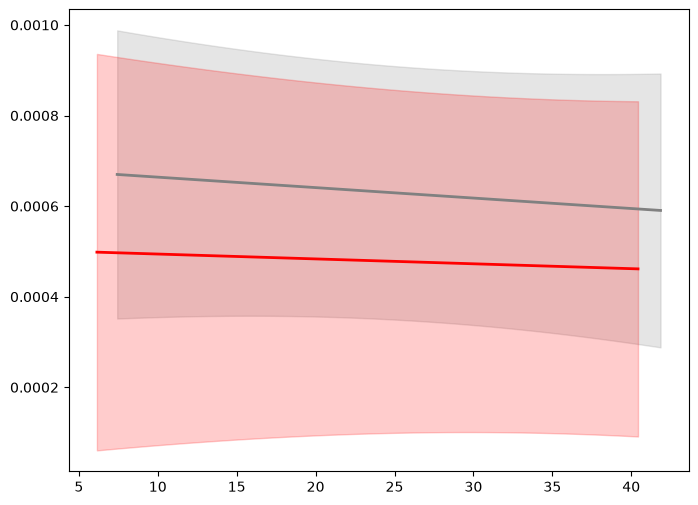

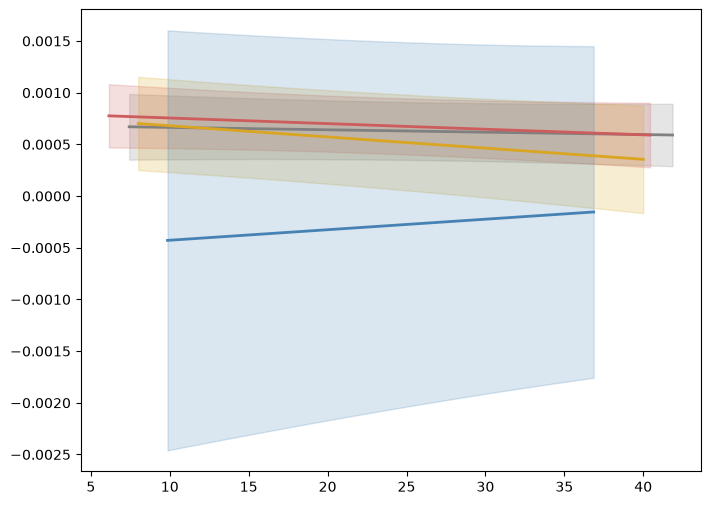

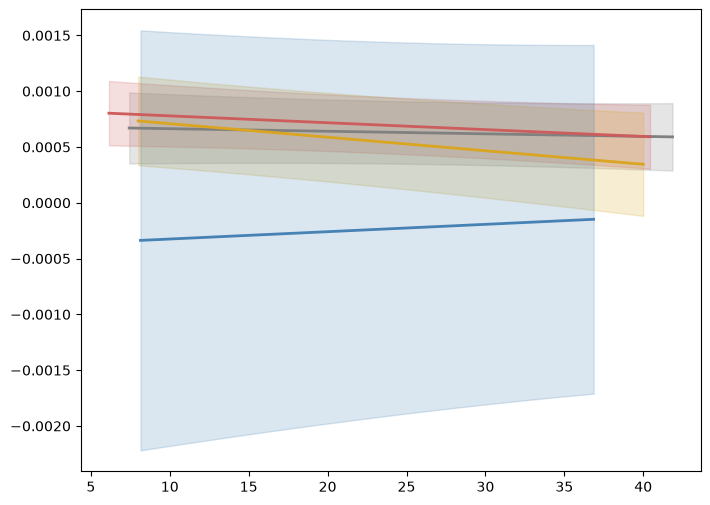

In [57]:
generate_trajectory_plots(list(decreased["analyte_ID"]), allPlasma, "/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/04_results_and_figures/trajectory_analysis/MTBL/decreased/pooled_complications", "plasma",  "MTBL", "pooled_complications")
generate_trajectory_plots(list(decreased["analyte_ID"]), allPlasma, "/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/04_results_and_figures/trajectory_analysis/MTBL/decreased/mutually_exclusive", "plasma",  "MTBL", "mutually_exclusive")
generate_trajectory_plots(list(decreased["analyte_ID"]), allPlasma, "/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/04_results_and_figures/trajectory_analysis/MTBL/decreased/non_mutually_exclusive", "plasma",  "MTBL", "non_mutually_exclusive")


In [58]:
decreased

,Unnamed: 0,analyte_ID,early_warning,complication_specific_1,complication_specific_2,complication_specific_3,total,complication_specific_4,most_prevalent,most_extreme_5,most_persistent,most_extreme_1,most_extreme_3,most_extreme_2,most_extreme_4
0,49,Hydroxydehydro Nifedipine Carboxylate_POS,"{'n_patients_decreased_at_earliest': 7, 'perce...",NaN,NaN,NaN,4,"{'group': 'HDP', 'reference': 'sPTB', 'gestati...","{'n_patients_affected': 12, 'percent_complicat...","{'n_patients_affected': 5, 'median_MAD_score':...",NaN,NaN,NaN,NaN,NaN
1,57,1-Nitrohydroxyphenyl-N-benzoylalanine_POS,"{'n_patients_decreased_at_earliest': 12, 'perc...","{'group': 'HDP', 'reference': 'sPTB', 'gestati...","{'group': 'HDP', 'reference': 'sPTB', 'gestati...",NaN,4,"{'group': 'HDP', 'reference': 'FGR', 'gestatio...","{'n_patients_affected': 13, 'percent_complicat...",NaN,"{'n_patients_affected': 13, 'mean_outlier_time...",NaN,NaN,NaN,NaN
2,99,unk_p2069_POS_481.8174_RT6.05,"{'n_patients_decreased_at_earliest': 8, 'perce...","{'group': 'FGR', 'reference': 'sPTB', 'gestati...","{'group': 'FGR', 'reference': 'sPTB', 'gestati...",NaN,4,NaN,"{'n_patients_affected': 9, 'percent_complicati...",NaN,"{'n_patients_affected': 9, 'mean_outlier_timep...",NaN,NaN,NaN,NaN
3,104,"6,7-dihydroxy-4,5,6,7-tetrahydroindole-4-one_NEG","{'n_patients_decreased_at_earliest': 8, 'perce...","{'group': 'sPTB', 'reference': 'FGR', 'gestati...","{'group': 'sPTB', 'reference': 'FGR', 'gestati...","{'group': 'sPTB', 'reference': 'HDP', 'gestati...",4,"{'group': 'sPTB', 'reference': 'FGR', 'gestati...","{'n_patients_affected': 8, 'percent_complicati...",NaN,NaN,"{'n_patients_affected': 8, 'median_MAD_score':...",NaN,NaN,NaN
4,144,3-Hydroxymepivacaine_POS,NaN,NaN,"{'group': 'sPTB', 'reference': 'FGR', 'gestati...",NaN,3,NaN,"{'n_patients_affected': 9, 'percent_complicati...",NaN,NaN,NaN,"{'n_patients_affected': 9, 'median_MAD_score':...","{'n_patients_affected': 5, 'median_MAD_score':...",NaN
5,164,V-Pyrro/NO_POS,"{'n_patients_decreased_at_earliest': 7, 'perce...","{'group': 'sPTB', 'reference': 'HDP', 'gestati...","{'group': 'sPTB', 'reference': 'HDP', 'gestati...","{'group': 'sPTB', 'reference': 'HDP', 'gestati...",3,NaN,"{'n_patients_affected': 9, 'percent_complicati...",NaN,NaN,NaN,NaN,NaN,NaN
6,168,unk_p4571_POS_347.8494_RT2.42,NaN,NaN,"{'group': 'sPTB', 'reference': 'FGR', 'gestati...",NaN,3,NaN,"{'n_patients_affected': 9, 'percent_complicati...",NaN,NaN,NaN,NaN,"{'n_patients_affected': 5, 'median_MAD_score':...",NaN
7,170,unk_p3493_POS_276.1361_RT4.66,"{'n_patients_decreased_at_earliest': 9, 'perce...","{'group': 'sPTB', 'reference': 'HDP', 'gestati...","{'group': 'sPTB', 'reference': 'HDP', 'gestati...","{'group': 'sPTB', 'reference': 'HDP', 'gestati...",3,"{'group': 'sPTB', 'reference': 'HDP', 'gestati...","{'n_patients_affected': 9, 'percent_complicati...",NaN,NaN,NaN,NaN,NaN,NaN
8,240,N-acetyl zonisamide_POS,"{'n_patients_decreased_at_earliest': 8, 'perce...",NaN,"{'group': 'sPTB', 'reference': 'FGR', 'gestati...","{'group': 'sPTB', 'reference': 'FGR', 'gestati...",3,NaN,"{'n_patients_affected': 10, 'percent_complicat...",NaN,NaN,NaN,NaN,NaN,NaN
9,248,2-Aminothiazole_POS,NaN,NaN,"{'group': 'FGR', 'reference': 'sPTB', 'gestati...",NaN,3,NaN,NaN,"{'n_patients_affected': 5, 'median_MAD_score':...","{'n_patients_affected': 6, 'mean_outlier_timep...",NaN,"{'n_patients_affected': 6, 'median_MAD_score':...",NaN,NaN


In [61]:
list(elevated["analyte_ID"])

['NP-003117_POS',
 'HMBOA trihexose_POS',
 'Hydroxydehydro Nifedipine Carboxylate_POS',
 '3-hydroxyoctanoyl carnitine_POS',
 'D-Raffinose_POS',
 '3-Methylheptanoylcarnitine_POS',
 'PEG n5_POS',
 'Desmethylcitalopram_POS',
 'Aladapcin_POS',
 'Citalopram hydrobromide_POS',
 'Octylphosphonic acid_POS',
 '[Similar to: 2-{[(2R,3R,4S,5S,6R)-4,5-dihydroxy-6-(hydroxymethyl)-3-{[(2S,3R,4R,5R,6S)-3,4,5-trihydroxy-6-methyloxan-2-yl]oxy}oxan-2-yl]oxy}-2-(4-hydroxyphenyl)acetonitrile; ΔMass: -157.9643 Da]_POS',
 'unk_p1632_POS_663.4347_RT12.76',
 '3-Hydroxybupivicaine_POS',
 'PEG n12_POS',
 'tert-Butyl N-[1-(aminocarbonyl)-3-methylbutyl]carbamate_POS',
 '3-(dimethylamino)-1-(2-pyridyl)prop-2-en-1-one_POS',
 '1-[2-(2,5-Dimethyl-1H-pyrrol-1-yl)-4-nitrophenyl]-4-(methylsulfonyl)piperazine_POS',
 '3-Hydroxysebacic acid_POS',
 '(2S,8R)-2-Amino-8-hydroxydecanoic acid_POS',
 '2-Octenoylcarnitine_POS',
 'N-(3-acetamidopropyl)pyrrolidin-2-one_POS']